In [1]:
import sys, os
PROJECT_ROOT = os.path.abspath("/Users/charles/Documents/PhD/Analysis/ieeg-pipeline")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from analysis.decoding.config import *
from analysis.decoding.loader import GroupLoader
from analysis.decoding.process_features import Features
from tqdm import tqdm
import nilearn.datasets
from nibabel.affines import apply_affine

mni_tmp = nilearn.datasets.load_mni152_template()
plt.style.use('seaborn-v0_8-poster') 


In [31]:
tmin = -1.5
tmax = 1.5
subjects = [2]
group = GroupLoader(subjects, tmin = -1.5, tmax = 1.5)
group.load_anatomy()
group.load_behavior("hmm")



In [32]:
for var in ["choice", "fb", "firstswitch", "goodswitch", "good_strat", "is_random", "is_stimstable"]:
    group.load_decoding_score(5, var, "linearsvc", "hmm", "global")
    group.load_decoding_betas(5, var, "linearsvc", "hmm", "global")

([<matplotlib.axis.XTick at 0x16b37bef0>,
 [Text(0.0, 0, '-1.5'),
  Text(128.0, 0, '-1.0'),
  Text(256.0, 0, '-0.5'),
  Text(384.0, 0, '0.0'),
  Text(512.0, 0, '0.5'),
  Text(640.0, 0, '1.0'),
  Text(768.0, 0, '1.5')])

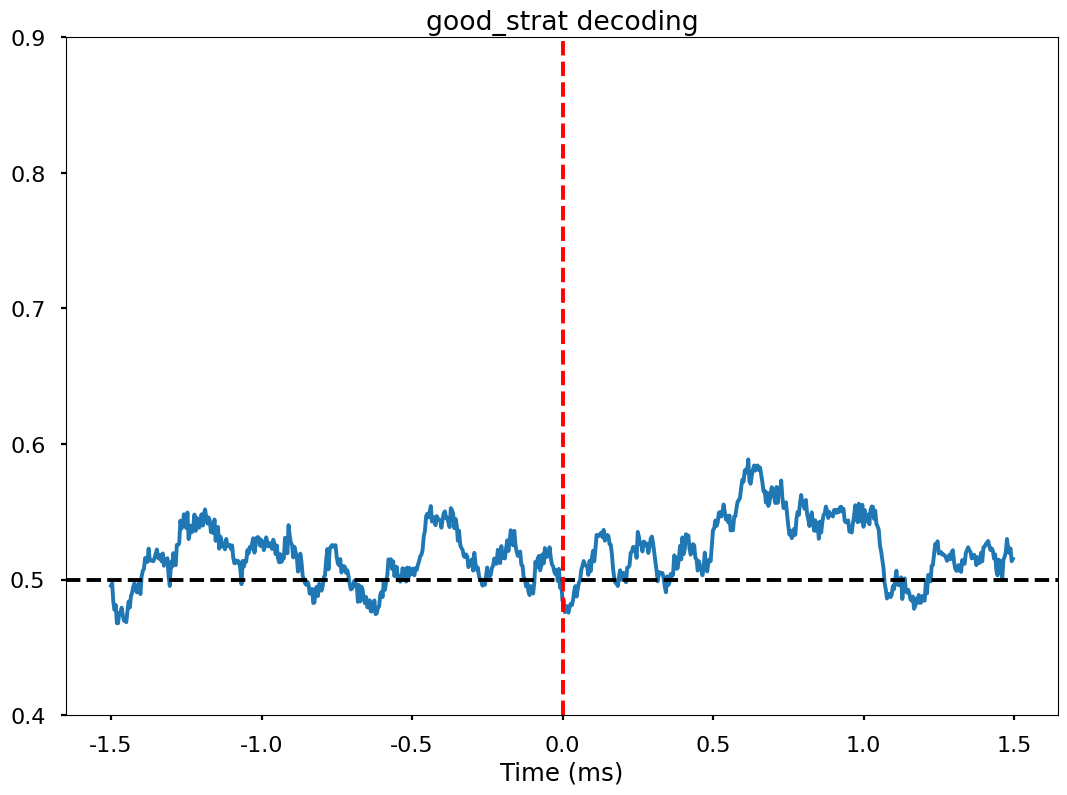

In [68]:
var = "good_strat"  
score_mat = group.global_score[var].T

timearray = np.linspace(tmin, tmax, int((np.abs(tmin) + tmax)*2+1))
arranged_timearray = np.arange(0, group.n_timepoints +1, group.n_timepoints/(len(timearray)-1))

plt.plot(score_mat)
plt.axhline(0.5, color='black', linestyle='--')
plt.axvline(1.5*sr_decimated, color='red', linestyle='--')
plt.title(f"{var} decoding")
plt.xlabel("Time (ms)")
plt.ylim((0.4, 0.9))
plt.xticks(ticks=arranged_timearray, labels=timearray)

([<matplotlib.axis.XTick at 0x1776cce90>,
 [Text(0.0, 0, '-1.5'),
  Text(128.0, 0, '-1.0'),
  Text(256.0, 0, '-0.5'),
  Text(384.0, 0, '0.0'),
  Text(512.0, 0, '0.5'),
  Text(640.0, 0, '1.0'),
  Text(768.0, 0, '1.5')])

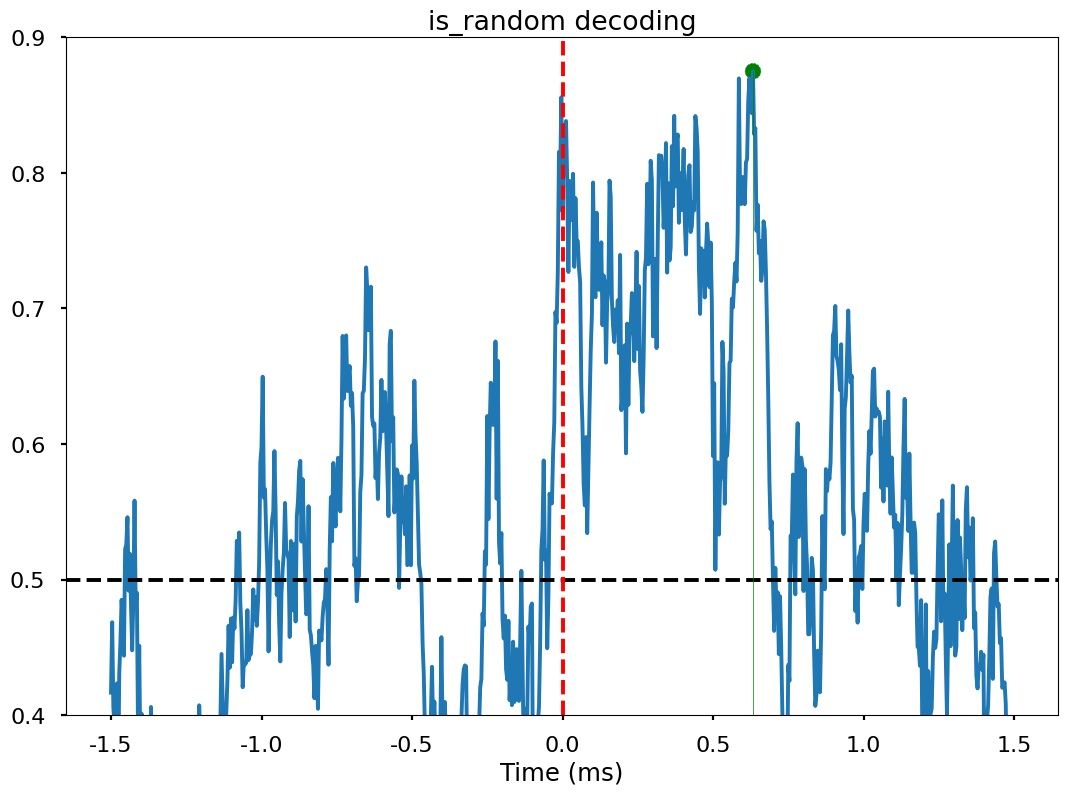

In [59]:

peak_time = np.argmax(score_mat, axis = 0)
plt.plot(score_mat)
plt.axhline(0.5, color='black', linestyle='--')
plt.axvline(1.5*sr_decimated, color='red', linestyle='--')

for i, peak in enumerate(peak_time):
    plt.scatter(peak, score_mat[peak, i], color='green', linestyle='--')
    plt.plot([peak, peak], [0.4, score_mat[peak, i]] , color='green', lw = 0.5)

plt.title(f"{var} decoding")
plt.xlabel("Time (ms)")
plt.ylim((0.4, 0.9))
plt.xticks(ticks=arranged_timearray, labels=timearray)

In [60]:
beta_mat = group.global_betas[var].T


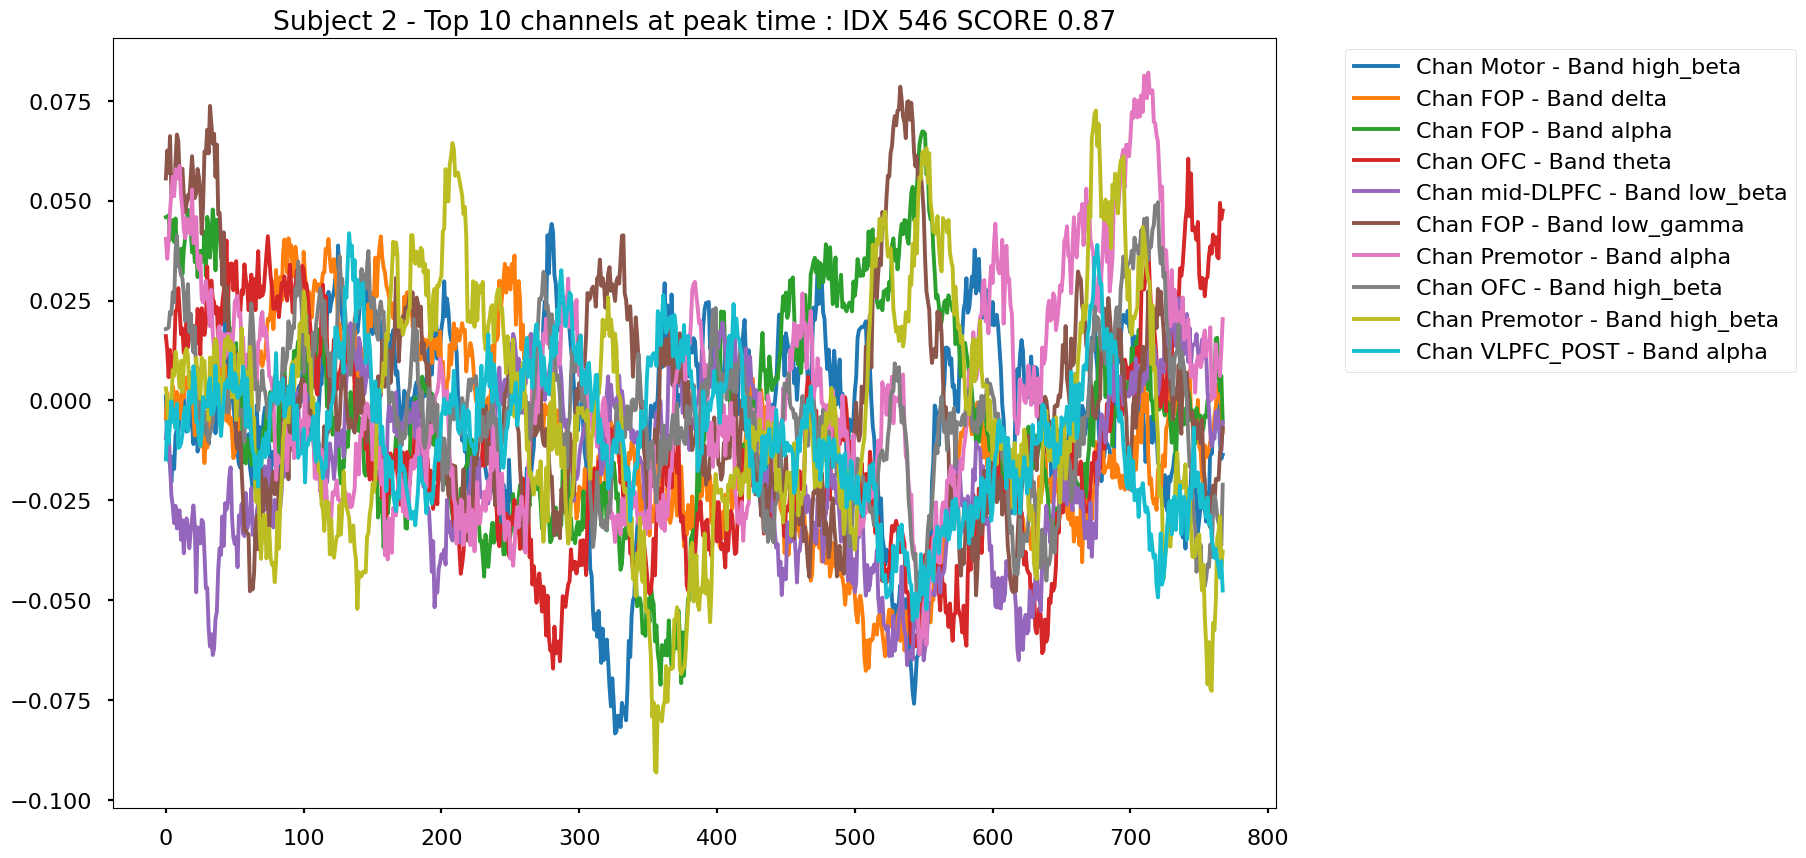

In [61]:
fig, axs = plt.subplots(len(subjects), 1, figsize = (15, 10))
# axs = axs.flatten()
axs = [axs]
n_bests = 10
best_channel = []
best_band = []
for i in range(len(subjects)):
    idx_channel = group.anatomy_data.loc[group.anatomy_data['subject'] == subjects[i], "chan_idx_global"].values
    beta_best_indiv = beta_mat[:, idx_channel, peak_time[i]].T
    for j in range(1, n_bests+1) :
        idx_beta = np.argsort(np.ravel(np.abs(beta_best_indiv)))[-j]
        chan, band = np.unravel_index(idx_beta, beta_best_indiv.shape)
        best_channel.append(idx_channel[chan])
        best_band.append(band)
        axs[i].plot(beta_mat[band, best_channel[-1], :], label = f"Chan {group.anatomy_data.loc[best_channel[-1], 'region']} - Band {list(FREQUENCY_BANDS.keys())[band]}")
    axs[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axs[i].set_title(f"Subject {subjects[i]} - Top {n_bests} channels at peak time : IDX {peak_time[i]} SCORE {score_mat[peak_time[i], i]:.2f}")
    # im = axs[i].imshow(beta_best_indiv, aspect = 'auto', origin = "lower", cmap = 'jet')
    # plt.colorbar(im, ax = axs[i])

In [62]:
best_channel = np.array(best_channel).reshape(len(subjects), -1)
best_band = np.array(best_band).reshape(len(subjects), -1)


In [63]:
best_channel_df = group.anatomy_data.loc[best_channel.flatten(), :].reset_index(drop=True)


In [64]:
ijk = np.round(apply_affine(np.linalg.inv(mni_tmp.affine),
                            best_channel_df[["x", "y", "z"]].to_numpy())).astype(int)
best_channel_df["i"], best_channel_df["j"], best_channel_df["k"] = ijk[:, 0], ijk[:, 1], ijk[:, 2]

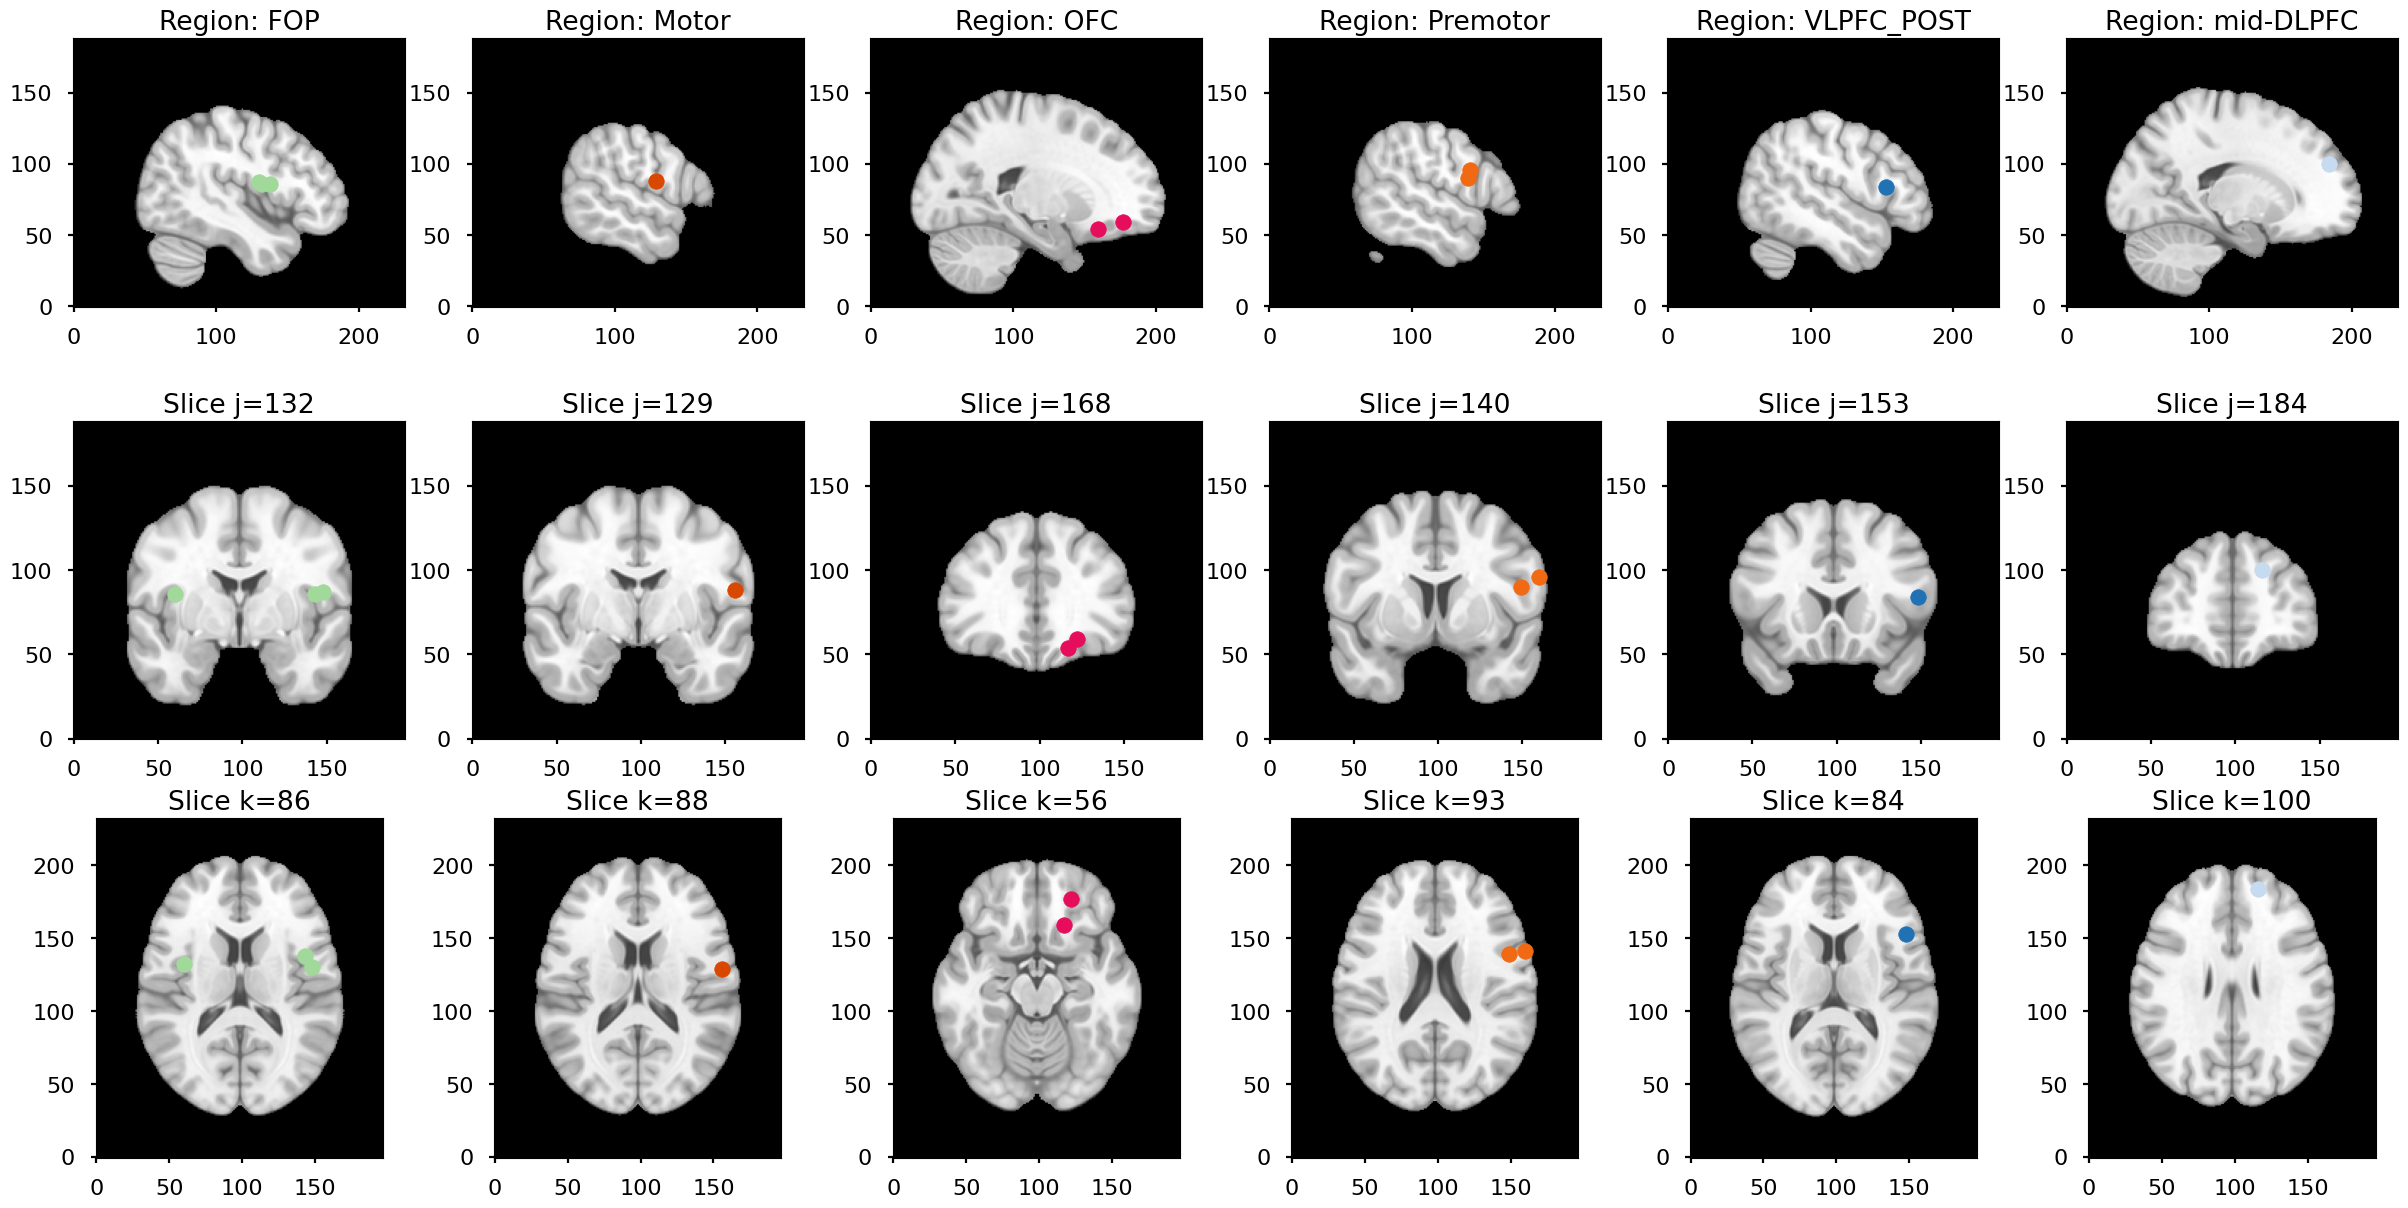

In [65]:
# i_mid = mni_tmp.shape[1]//2
# slices_idx = np.arange(mni_tmp.shape[1]//2+10, mni_tmp.shape[1]-20, (mni_tmp.shape[1]//2-30)//9)
n_region = best_channel_df["region"].unique()
nrows = len(n_region)
fig, axs = plt.subplots(3, nrows, figsize=(30, 15))
# axs = axs.flatten()

# for idx, row in best_channel_df.iterrows():
for i, (region, sdf) in enumerate(best_channel_df.groupby('region')):
    for j, coord in enumerate(["i", "j", "k"]):
        slice_idx = sdf[coord].median().astype(int)
        mni_img = mni_tmp.get_fdata()
        if coord == "i":
            slice_img = mni_img[slice_idx, :, :].T
        elif coord == "j":
            slice_img = mni_img[:, slice_idx, :].T
        elif coord == "k":
            slice_img = mni_img[:, :, slice_idx].T
        color = area_colors[region]
        for idx, row in sdf.iterrows():
            axs[j, i].imshow(slice_img, cmap='gray', origin='lower')
            if coord == "i":
                axs[j, i].scatter(row["j"], row["k"], c=color, label=region)
            elif coord == "j":
                axs[j, i].scatter(row["i"], row["k"], c=color, label=region)
            elif coord == "k":
                axs[j, i].scatter(row["i"], row["j"], c=color, label=region)
            if coord == "i":
                axs[j, i].set_title(f'Region: {region}')
            else : 
                axs[j, i].set_title(f'Slice {coord}={slice_idx}')


np.float64(134.0)